In [1]:
!pip install selenium pandas

In [3]:
import time
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options

In [5]:
url = "https://www.imdb.com/search/title/?title_type=feature&release_date=2024-01-01,2024-12-31"

options = Options()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(options=options)

driver.get(url)

time.sleep(5)

In [7]:
for i in range(15):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

In [9]:
movies = driver.find_elements(By.CLASS_NAME,"ipc-metadata-list-summary-item")

data = []

for m in movies:

    try:
        name = m.find_element(By.TAG_NAME,"h3").text
    except:
        name = None

    try:
        rating = m.find_element(By.CLASS_NAME,"ipc-rating-star--rating").text
    except:
        rating = None

    try:
        votes = m.find_element(By.CLASS_NAME,"ipc-rating-star--voteCount").text
    except:
        votes = None

    try:
        duration = m.find_element(By.XPATH,'.//span[contains(text(),"min")]').text
    except:
        duration = None

    data.append([name,rating,votes,duration])

print("Movies scraped:",len(data))

Movies scraped: 1000


In [11]:
columns = ["Movie Name","Rating","Votes","Duration"]

df = pd.DataFrame(data,columns=columns)

df.head()

,Movie Name,Rating,Votes,Duration
0,1. Abigail,6.5,(115K),None
1,2. The Substance,7.2,(408K),None
2,3. The Life of Chuck,7.3,(62K),None
3,4. Dune: Part Two,8.4,(720K),None
4,5. Eden,6.5,(41K),None


In [13]:
df["Movie Name"] = df["Movie Name"].str.replace(r"^\d+\.\s*", "", regex=True)

df.head()

,Movie Name,Rating,Votes,Duration
0,Abigail,6.5,(115K),None
1,The Substance,7.2,(408K),None
2,The Life of Chuck,7.3,(62K),None
3,Dune: Part Two,8.4,(720K),None
4,Eden,6.5,(41K),None


In [15]:
df["Votes"] = df["Votes"].str.replace("[(),K]", "", regex=True)

df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce") * 1000

df.head()

,Movie Name,Rating,Votes,Duration
0,Abigail,6.5,115000.0,None
1,The Substance,7.2,408000.0,None
2,The Life of Chuck,7.3,62000.0,None
3,Dune: Part Two,8.4,720000.0,None
4,Eden,6.5,41000.0,None


In [17]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df.head()

,Movie Name,Rating,Votes,Duration
0,Abigail,6.5,115000.0,None
1,The Substance,7.2,408000.0,None
2,The Life of Chuck,7.3,62000.0,None
3,Dune: Part Two,8.4,720000.0,None
4,Eden,6.5,41000.0,None


In [19]:
df["Duration"] = df["Duration"].fillna("Unknown")

df.head()

,Movie Name,Rating,Votes,Duration
0,Abigail,6.5,115000.0,Unknown
1,The Substance,7.2,408000.0,Unknown
2,The Life of Chuck,7.3,62000.0,Unknown
3,Dune: Part Two,8.4,720000.0,Unknown
4,Eden,6.5,41000.0,Unknown


In [21]:
df.to_csv("IMDB_2024_movies_cleaned.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("IMDB_2024_movies_cleaned.csv")

df.head()

,Movie Name,Rating,Votes,Duration
0,Abigail,6.5,115000.0,Unknown
1,The Substance,7.2,408000.0,Unknown
2,The Life of Chuck,7.3,62000.0,Unknown
3,Dune: Part Two,8.4,720000.0,Unknown
4,Eden,6.5,41000.0,Unknown


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Movie Name  1000 non-null   object 
 1   Rating      999 non-null    float64
 2   Votes       999 non-null    float64
 3   Duration    1000 non-null   object 
dtypes: float64(2), object(2)
memory usage: 31.4+ KB


In [27]:
top_rated = df.sort_values(by="Rating", ascending=False).head(10)

top_rated

,Movie Name,Rating,Votes,Duration
169,Attack on Titan the Movie: The Last Attack,9.2,25000.0,Unknown
619,Zeitgeist: Requiem,9.2,90000.0,Unknown
912,Paper Bag Plan,9.2,39000.0,Unknown
933,The Friendly,9.0,51000.0,Unknown
504,Space Cowboy,9.0,62000.0,Unknown
956,Gundi: Legend of Love,8.9,5900.0,Unknown
847,Re: Zero - Starting Life in Another World- Sea...,8.8,1700.0,Unknown
924,Gunfighter Paradise,8.7,25000.0,Unknown
213,Solo Leveling: ReAwakening,8.7,17000.0,Unknown
918,GHOST: Rite Here Rite Now,8.6,2200.0,Unknown


In [29]:
top_voted = df.sort_values(by="Votes", ascending=False).head(10)

top_voted

,Movie Name,Rating,Votes,Duration
920,Horror in the High Desert 3: Firewatch,5.4,995000.0,Unknown
652,Block Pass,6.8,991000.0,Unknown
517,The Beldham,5.1,991000.0,Unknown
725,Corina,7.0,989000.0,Unknown
820,I Love You Forever,5.7,976000.0,Unknown
425,Mon Potongo,4.6,972000.0,Unknown
932,Shoutai,6.8,968000.0,Unknown
459,Dead Money,5.8,953000.0,Unknown
830,Audrey's Children,6.8,945000.0,Unknown
887,Meet the Barbarians,6.4,931000.0,Unknown


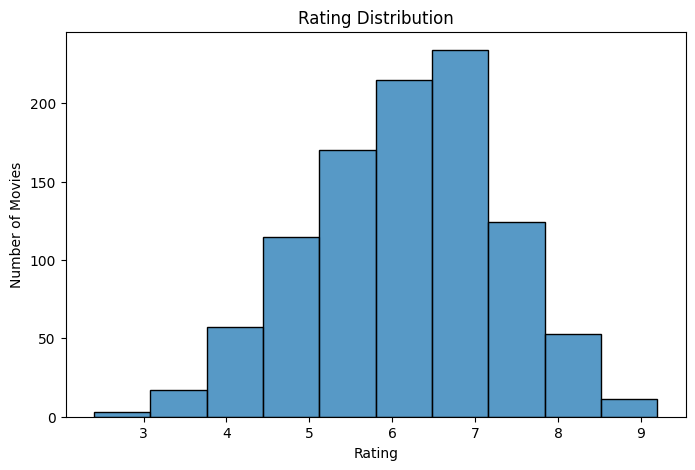

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()

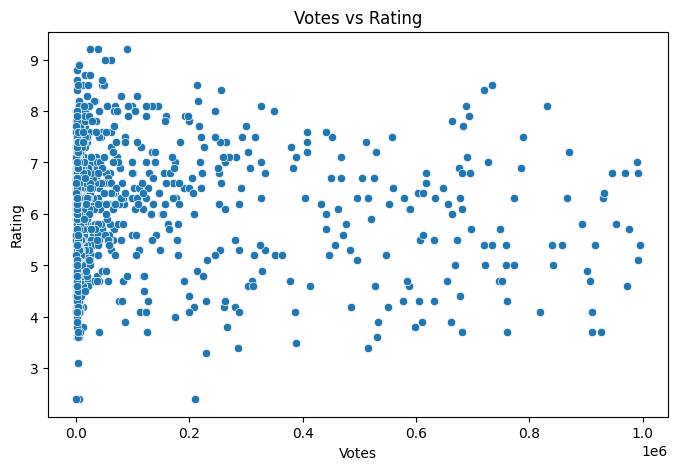

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Votes", y="Rating", data=df)

plt.title("Votes vs Rating")
plt.show()

In [35]:
top_rated.to_csv("top_rated_movies.csv", index=False)

top_voted.to_csv("top_voted_movies.csv", index=False)

In [37]:
df["Genre"] = "Unknown"
df["Duration"] = "Unknown"

df = df[["Movie Name","Genre","Rating","Votes","Duration"]]

df.head()

,Movie Name,Genre,Rating,Votes,Duration
0,Abigail,Unknown,6.5,115000.0,Unknown
1,The Substance,Unknown,7.2,408000.0,Unknown
2,The Life of Chuck,Unknown,7.3,62000.0,Unknown
3,Dune: Part Two,Unknown,8.4,720000.0,Unknown
4,Eden,Unknown,6.5,41000.0,Unknown


In [39]:
import os

folder = "genre_csv"

if not os.path.exists(folder):
    os.makedirs(folder)

for genre in df["Genre"].unique():
    
    genre_df = df[df["Genre"] == genre]
    
    file_name = f"{folder}/{genre}_2024.csv"
    
    genre_df.to_csv(file_name, index=False)

print("Genre-wise CSV files saved")

Genre-wise CSV files saved


In [41]:
import glob

csv_files = glob.glob("genre_csv/*.csv")

combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

combined_df.to_csv("IMDB_2024_combined.csv", index=False)

combined_df.head()

,Movie Name,Genre,Rating,Votes,Duration
0,Abigail,Unknown,6.5,115000.0,Unknown
1,The Substance,Unknown,7.2,408000.0,Unknown
2,The Life of Chuck,Unknown,7.3,62000.0,Unknown
3,Dune: Part Two,Unknown,8.4,720000.0,Unknown
4,Eden,Unknown,6.5,41000.0,Unknown


In [43]:
pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [45]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///imdb_movies.db")

combined_df.to_sql("movies_2024", engine, if_exists="replace", index=False)

print("Data stored in SQL database")

Data stored in SQL database


In [47]:
query = "SELECT * FROM movies_2024 LIMIT 10"

sql_df = pd.read_sql(query, engine)

sql_df

,Movie Name,Genre,Rating,Votes,Duration
0,Abigail,Unknown,6.5,115000.0,Unknown
1,The Substance,Unknown,7.2,408000.0,Unknown
2,The Life of Chuck,Unknown,7.3,62000.0,Unknown
3,Dune: Part Two,Unknown,8.4,720000.0,Unknown
4,Eden,Unknown,6.5,41000.0,Unknown
5,Anora,Unknown,7.4,265000.0,Unknown
6,We Bury the Dead,Unknown,5.6,8900.0,Unknown
7,Blink Twice,Unknown,6.5,127000.0,Unknown
8,Furiosa: A Mad Max Saga,Unknown,7.5,316000.0,Unknown
9,Relay,Unknown,7.0,31000.0,Unknown


In [49]:
sql_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Movie Name  10 non-null     object 
 1   Genre       10 non-null     object 
 2   Rating      10 non-null     float64
 3   Votes       10 non-null     float64
 4   Duration    10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [51]:
sql_df.isnull().sum()

Movie Name    0
Genre         0
Rating        0
Votes         0
Duration      0
dtype: int64

In [53]:
top_movies = sql_df.sort_values(by="Rating", ascending=False).head(10)
top_movies

,Movie Name,Genre,Rating,Votes,Duration
3,Dune: Part Two,Unknown,8.4,720000.0,Unknown
8,Furiosa: A Mad Max Saga,Unknown,7.5,316000.0,Unknown
5,Anora,Unknown,7.4,265000.0,Unknown
2,The Life of Chuck,Unknown,7.3,62000.0,Unknown
1,The Substance,Unknown,7.2,408000.0,Unknown
9,Relay,Unknown,7.0,31000.0,Unknown
0,Abigail,Unknown,6.5,115000.0,Unknown
4,Eden,Unknown,6.5,41000.0,Unknown
7,Blink Twice,Unknown,6.5,127000.0,Unknown
6,We Bury the Dead,Unknown,5.6,8900.0,Unknown


In [55]:
sql_df.sort_values(by="Votes", ascending=False).head(10)

,Movie Name,Genre,Rating,Votes,Duration
3,Dune: Part Two,Unknown,8.4,720000.0,Unknown
1,The Substance,Unknown,7.2,408000.0,Unknown
8,Furiosa: A Mad Max Saga,Unknown,7.5,316000.0,Unknown
5,Anora,Unknown,7.4,265000.0,Unknown
7,Blink Twice,Unknown,6.5,127000.0,Unknown
0,Abigail,Unknown,6.5,115000.0,Unknown
2,The Life of Chuck,Unknown,7.3,62000.0,Unknown
4,Eden,Unknown,6.5,41000.0,Unknown
9,Relay,Unknown,7.0,31000.0,Unknown
6,We Bury the Dead,Unknown,5.6,8900.0,Unknown


In [57]:
sql_df.sort_values(by="Duration", ascending=False).head(10)

,Movie Name,Genre,Rating,Votes,Duration
0,Abigail,Unknown,6.5,115000.0,Unknown
1,The Substance,Unknown,7.2,408000.0,Unknown
2,The Life of Chuck,Unknown,7.3,62000.0,Unknown
3,Dune: Part Two,Unknown,8.4,720000.0,Unknown
4,Eden,Unknown,6.5,41000.0,Unknown
5,Anora,Unknown,7.4,265000.0,Unknown
6,We Bury the Dead,Unknown,5.6,8900.0,Unknown
7,Blink Twice,Unknown,6.5,127000.0,Unknown
8,Furiosa: A Mad Max Saga,Unknown,7.5,316000.0,Unknown
9,Relay,Unknown,7.0,31000.0,Unknown


In [59]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

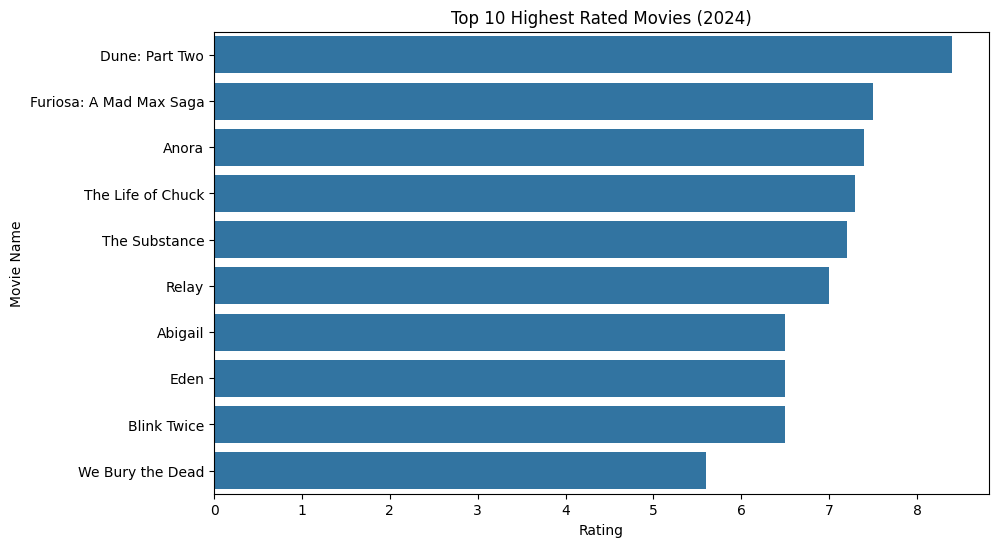

In [63]:
top_movies = sql_df.sort_values(by="Rating", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Rating", y="Movie Name", data=top_movies)

plt.title("Top 10 Highest Rated Movies (2024)")
plt.xlabel("Rating")
plt.ylabel("Movie Name")

plt.show()

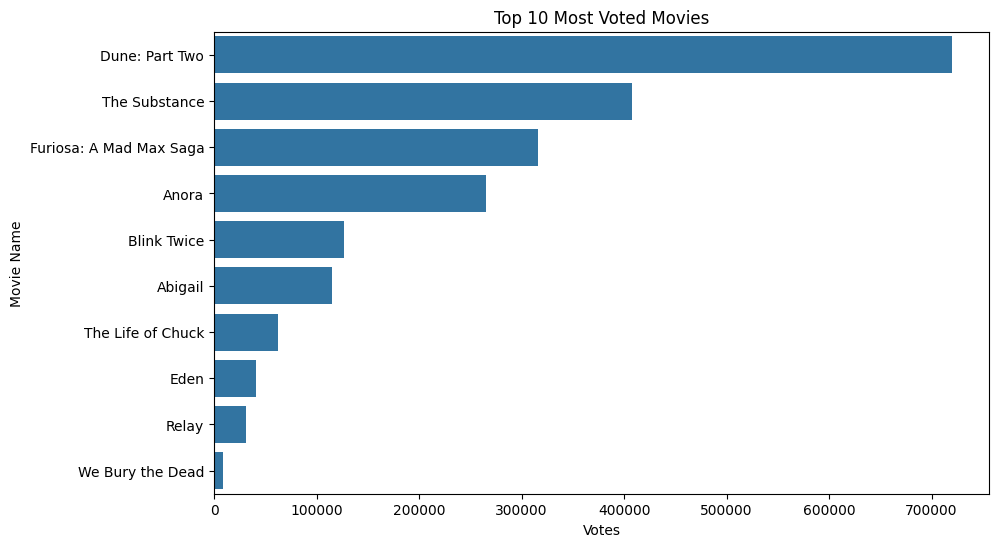

In [65]:
top_votes = sql_df.sort_values(by="Votes", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Votes", y="Movie Name", data=top_votes)

plt.title("Top 10 Most Voted Movies")
plt.xlabel("Votes")
plt.ylabel("Movie Name")

plt.show()

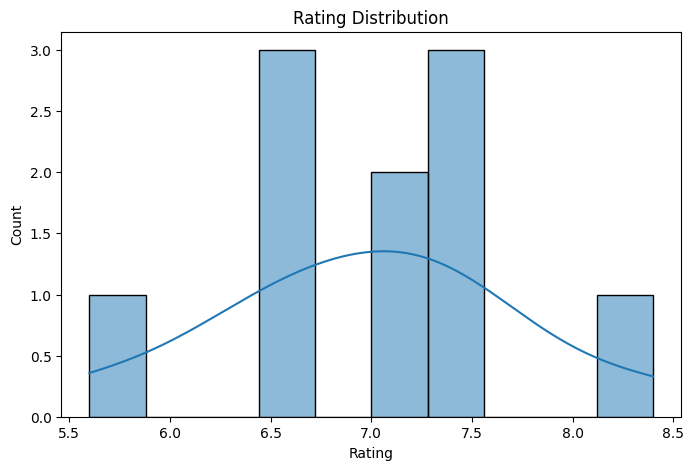

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(sql_df["Rating"], bins=10, kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()